<a href="https://colab.research.google.com/github/Ricardo428/Red-Convolutiva/blob/main/Modelo_6_Transfer_learnig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo Transfer learning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Cambio en el modelo

En la transformación he añadido una mayor variedad a las imagenes rotandolas y volteandolas

Como en algunos modelos vistos

In [ ]:
# Importa las librerías necesarias de PyTorch
import torch
import torchvision
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torch import nn,optim


#Relizamos la transformación para asegurar uniformidad en el conjunto
transformn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



ruta = '/content/drive/MyDrive/dataset'#Esto es una carpeta que está dentro del GoogleDrive

# Cargamos el dataset
train_data = datasets.ImageFolder(root=ruta + "/train",transform = transformn)
test_data = datasets.ImageFolder(root=ruta + "/test",transform = transformn)
valid_data = datasets.ImageFolder(root=ruta + "/validation",transform = transformn)


# Imprime los valores máximo y mínimo de un píxel en la primera imagen (después de la normalización)
# Obtenemos el valor máximo y mínimo, que están en el baremo de [-1, 1]
print("Maximo valor de la imagen:",train_data[0][0].squeeze().max())
print("Minimo valor de la imagen:",train_data[0][0].squeeze().min())

# Informacion del dataset
print("\n--- Información del dataset ---")
print(f"Clases encontradas: {train_data.classes}")
print(f"Número de clases: {len(train_data.classes)}")
print(f"Num imagenes training: {len(train_data)}")
print(f"Num imagenes test: {len(test_data)}")
print(f"Num imagenes valid: {len(valid_data)}")

# Empaquetamos las imagenes en lotes de 32
train_loader = DataLoader(train_data,shuffle=True,batch_size=32)
test_loader = DataLoader(test_data,shuffle=False,batch_size=32)
valid_loader = DataLoader(valid_data,shuffle=False,batch_size=32)


Maximo valor de la imagen: tensor(2.6400)
Minimo valor de la imagen: tensor(-2.1179)

--- Información del dataset ---
Clases encontradas: ['bus', 'car', 'motorcycle', 'train', 'truck']
Número de clases: 5
Num imagenes training: 5418
Num imagenes test: 708
Num imagenes valid: 709


In [ ]:
# Cargamos el modelo VGG16 preentrenado
# model_conv = torchvision.models.vgg16()
vgg16 = torchvision.models.vgg16(weights='IMAGENET1K_V1')

#vgg16.features están las capas convolucionales
#vgg16.classifier están las capas fullyconnected

# Congelamos los pesos de todas las capas excepto las últimas 7 capas convolutivas
for param in vgg16.features[:-7].parameters():
    param.requires_grad = False

# Obtenemos el número de características de la última capa
in_features = vgg16.classifier[0].in_features

#print(in_features) # 25088

# Creamos un nuevo clasificador
cls = nn.Sequential(
    nn.Linear(in_features, 256),  # 4096 -> 256
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 5),
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Creamos un nuevo modelo con las features de vgg16 y el clasificador personalizado
net = nn.Sequential(
    vgg16.features,
    nn.Flatten(),
    cls
).to(device)

In [ ]:
#Instanciamiento de  la red
print(f'Usando {device}')

#Definimos la función de perdida y el optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr=0.0001,weight_decay=1e-4)

Usando cuda:0


In [ ]:
import torch
import torch.nn.functional as F

def evaluate(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Cálculo de la pérdida
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Cálculo de aciertos
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    acc = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, acc

In [ ]:
# Entrenamiento de la red
num_epochs = 5

# Almacenamiento de resultados
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
}

for epoch in range(num_epochs):
  epoch_loss = 0.0
  correct = 0
  total = 0

  net.train()
  for i, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Cálculo de las salidas (forward)
    outputs = net(images)

    # Cálculo de la perdida
    loss = loss_fn(outputs, labels)

    # Cálculo de gradientes(backward)
    loss.backward()

    # Actualizar los pesos
    optimizer.step()

    # Reseteo de los gradientes
    optimizer.zero_grad()

    # Acumular la pérdida
    epoch_loss += loss.item()

    # Cálculo de aciertos en el entrenamiento
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  # Resultados del entrenamiento
  epoch_train_loss = epoch_loss / len(train_loader)
  epoch_train_acc = 100.0 * correct / total

  # Cálculo de aciertos y pérdida (Validation)
  epoch_val_loss, epoch_val_acc = evaluate(net, valid_loader, loss_fn, device)

  # Historial
  history['train_loss'].append(epoch_train_loss)
  history['train_acc'].append(epoch_train_acc)

  history['val_loss'].append(epoch_val_loss)
  history['val_acc'].append(epoch_val_acc)

  print(f"[Ep {epoch+1}] "
        f"Train loss: {epoch_train_loss:.3f} accuracy: {epoch_train_acc:.1f}% | "
        f"Val loss: {epoch_val_loss:.3f} accuracy: {epoch_val_acc:.1f}%")


[Ep 1] Train loss: 0.644 accuracy: 75.0% | Val loss: 0.452 accuracy: 84.6%
[Ep 2] Train loss: 0.407 accuracy: 84.8% | Val loss: 0.484 accuracy: 84.8%
[Ep 3] Train loss: 0.370 accuracy: 86.5% | Val loss: 0.426 accuracy: 86.9%
[Ep 4] Train loss: 0.317 accuracy: 88.6% | Val loss: 0.436 accuracy: 86.5%
[Ep 5] Train loss: 0.279 accuracy: 89.8% | Val loss: 0.357 accuracy: 87.0%


In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model: {100 * correct / total}%')


Accuracy of the model: 87.71186440677967%


## Resultados
En el desarrollo de las épocas tenemos 2 metricas de cada conjunto (pérdida y precisión).Estas nos dejan ver el comportamiento de la red durante su entrenamineto.

Podemos observar que la red aprende perfectamente con los datos del entrenamiento la pérdida disminuye y la precisión aumenta, por lo que la red esta siendo capaz reconocer mejor los patrones de las imagenes.

Vemos que la técnica de transfer learning a dado resultados como se esperaba llegando a valores muy buenos superando en todos los conjuntos el 87 % de precisión.


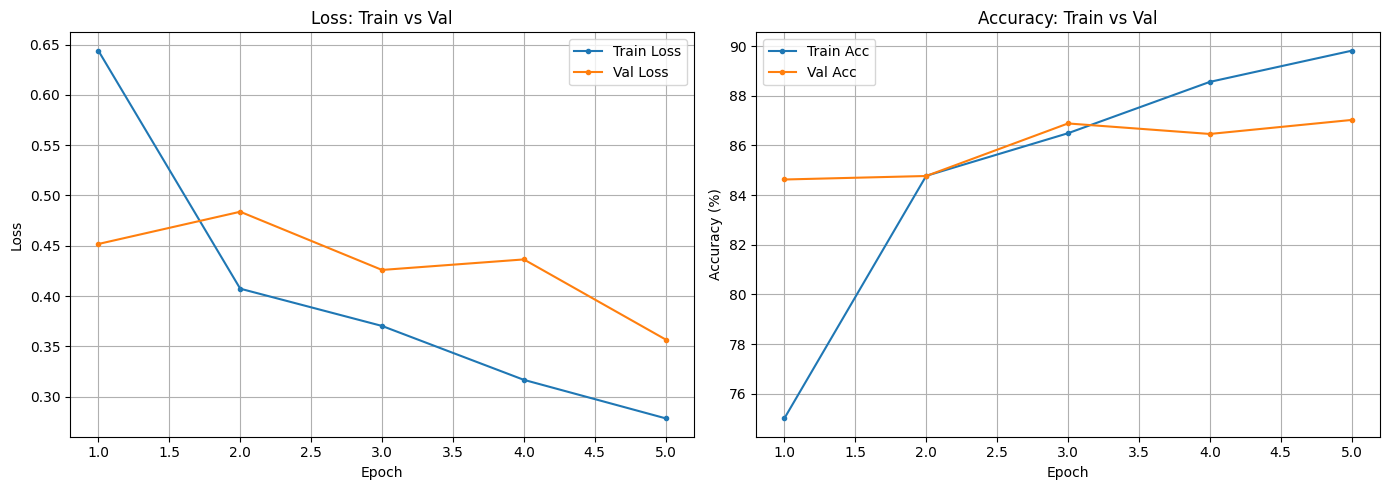

In [ ]:
import matplotlib.pyplot as plt


epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history['val_loss'],   label='Val Loss',   marker='.')


plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss: Train vs Val' )
plt.legend()
plt.grid(True)

# Gráfico de precisión
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history['val_acc'],   label='Val Acc',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy: Train vs Val')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Graficas

En las gráficas podemos observar el historial de perdidas y preciciones.

En la grafica de pérdida se ve que la tendencia es disminuir los valores,también podemos observar que el conjunto de validación al principio da mejores resultados que el conjunto de entrenamiento, sin embargo , en el desarrollo de las épocas el entrenamiento supera a la validación.

En la gráfica de precisión observamos que los porcentajes suben notablemente y como se dijo en la gráfica de pérdida que el conjutno de validación al principio da mejores resultados.

##Matrices de confusión

A continuación vemos las matrices de confusión del entrenamiento, test  y validación que nos dejan   analizar con mayor detalle el comportamiento con cada una de las clases y asi ver que clase le cuesta más clasificar.

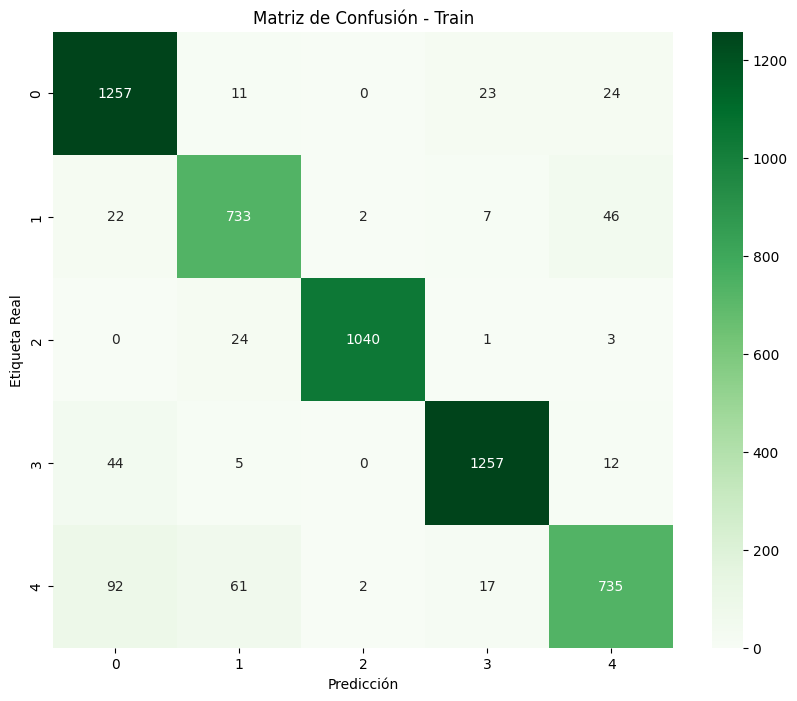

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

net.eval()

all_preds_test = []
all_labels_test = []

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Train')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

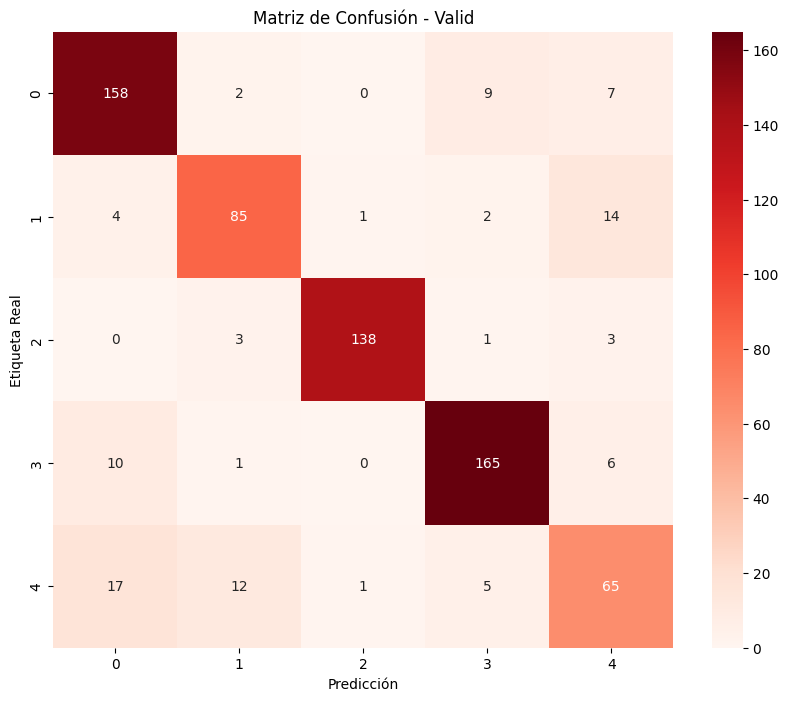

In [ ]:
net.eval()

all_preds_test = []
all_labels_test = []

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusión - Valid')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

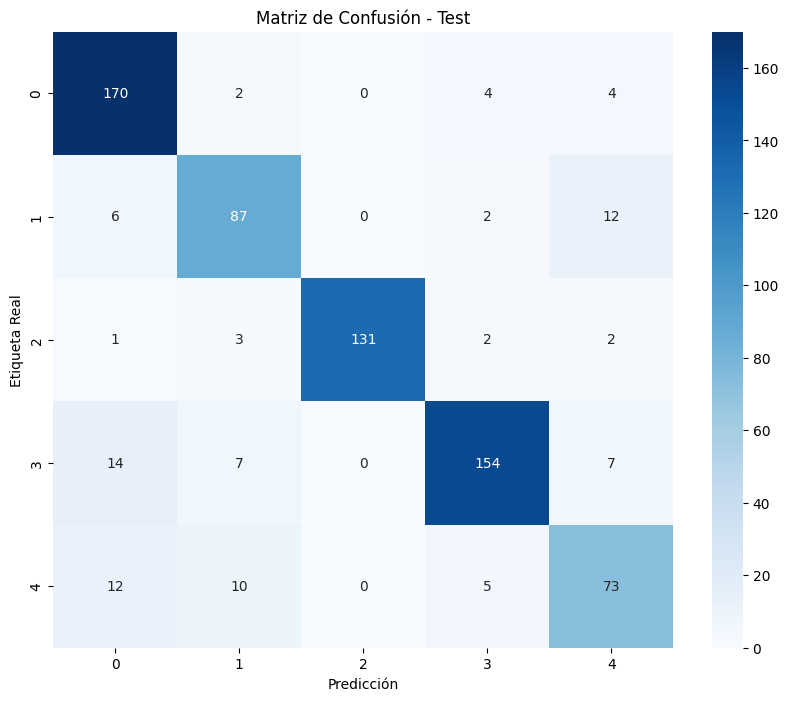

In [ ]:
net.eval()

all_preds_train = []
all_labels_train = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

conf_matrix_train = confusion_matrix(all_labels_train, all_preds_train)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Test')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

##Resultado de la visualización de las matrices de confusión

Las matrices de confusión revelan que el modelo tiene más dificultades con la segunda y quinta clase. Esto era predecible debido al desbalanceo del dataset: estas clases contaban con menos imagenes que el resto, lo que dificulta que la red aprenda a classificarlas correctamente.